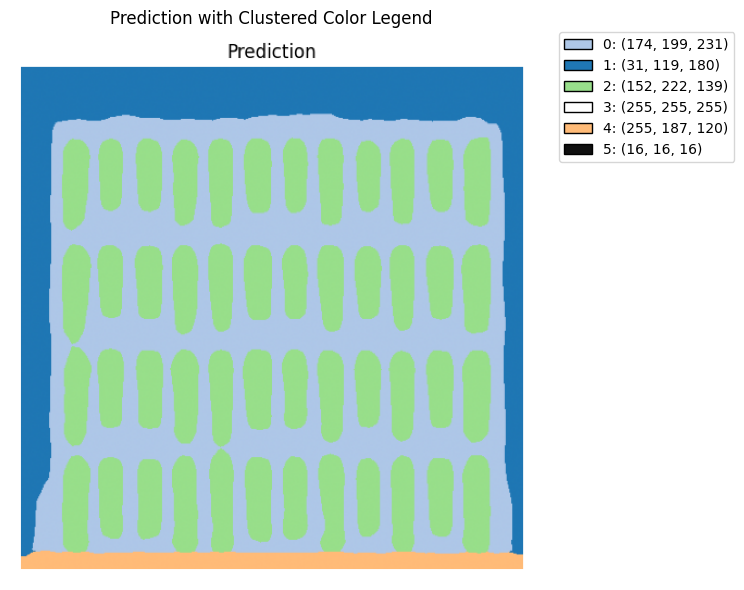

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.patches import Patch

# Load image and convert to RGB
img = cv2.imread("../data-samples/model_outputs/output.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pixels = img_rgb.reshape(-1, 3)

# Set number of expected classes 
NUM_CLASSES = 6  # e.g. background, building, window, ground

# Cluster colors
kmeans = KMeans(n_clusters=NUM_CLASSES, random_state=0).fit(pixels)
colors = np.rint(kmeans.cluster_centers_).astype(np.uint8)

# Create legend
legend_elements = []
for i, color in enumerate(colors):
    label = f"{i}: {tuple(color)}"
    legend_elements.append(Patch(facecolor=color/255.0, edgecolor='black', label=label))

# Show image with color legend
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Prediction with Clustered Color Legend")
plt.tight_layout()
plt.show()


In [5]:
# Set color
window_color = np.array([152, 222, 139])  

# Define tolerance
tolerance = 20
lower = np.clip(window_color - tolerance, 0, 255)
upper = np.clip(window_color + tolerance, 0, 255)

# Create window mask
window_mask = cv2.inRange(img_rgb, lower, upper)


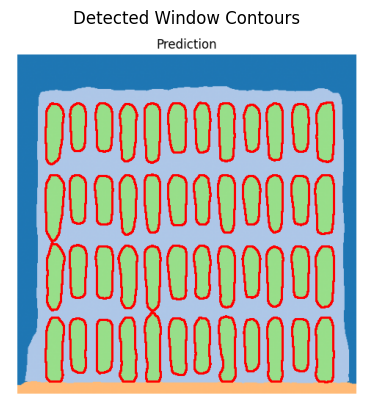

In [6]:
# Find contours
contours, _ = cv2.findContours(window_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw for debug
img_debug = img_rgb.copy()
cv2.drawContours(img_debug, contours, -1, (255, 0, 0), 2)
plt.imshow(img_debug)
plt.title("Detected Window Contours")
plt.axis("off")
plt.show()


In [7]:
# Dummy pixel-to-cm scale
known_height_px = 600
known_height_cm = 300
pixels_per_cm = known_height_px / known_height_cm  # 2 px/cm

# Measure windows
window_measurements = []

for i, cnt in enumerate(contours):
    x, y, w, h = cv2.boundingRect(cnt)

    window_measurements.append({
        "Window ID": i + 1,
        "Top (px)": y,
        "Bottom (px)": y + h,
        "Left (px)": x,
        "Right (px)": x + w,
        "Width (px)": w,
        "Height (px)": h,
        "Width (cm)": round(w / pixels_per_cm, 2),
        "Height (cm)": round(h / pixels_per_cm, 2)
    })

In [8]:
# Display as table
df = pd.DataFrame(window_measurements)
print(df)

NameError: name 'pd' is not defined

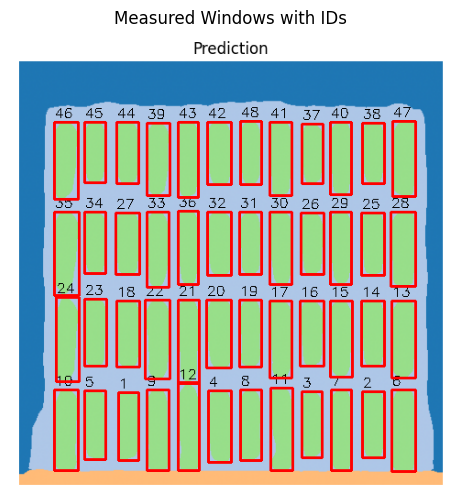

In [ ]:
img_out = img_rgb.copy()
for i, cnt in enumerate(contours):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_out, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(img_out, f"{i+1}", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

plt.figure(figsize=(10, 6))
plt.imshow(img_out)
plt.title("Measured Windows with IDs")
plt.axis("off")
plt.show()

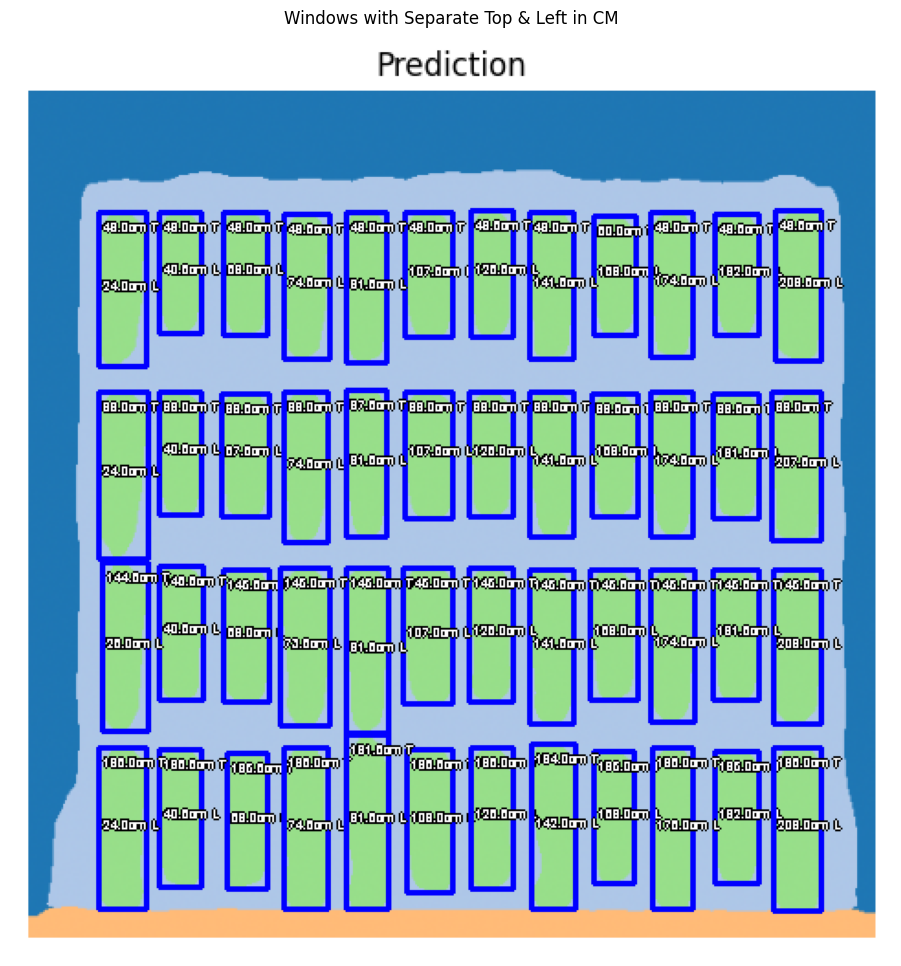

In [ ]:
img_out = img_rgb.copy()

for i, cnt in enumerate(contours):
    x, y, w, h = cv2.boundingRect(cnt)
    left_cm = round(x / pixels_per_cm, 1)
    top_cm = round(y / pixels_per_cm, 1)

    # Draw rectangle
    cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 0, 255), 2)

    # Annotate left (near left edge, vertically centered)
    left_text = f"{left_cm}cm L"
    left_pos = (x + 2, y + h // 2)
    cv2.putText(img_out, left_text, left_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.2, (0,0,0), 2)
    cv2.putText(img_out, left_text, left_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.2, (255,255,255), 1)

    # Annotate top (above the box)
    top_text = f"{top_cm}cm T"
    top_pos = (x + w // 10, y - -10)
    cv2.putText(img_out, top_text, top_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.2, (0,0,0), 2)
    cv2.putText(img_out, top_text, top_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.2, (255,255,255), 1)

plt.figure(figsize=(20, 12))
plt.imshow(img_out)
plt.title("Windows with Separate Top & Left in CM")
plt.axis("off")
plt.show()


In [21]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision
import cv2
import plotly.graph_objects as go

# ------------------------------
# Load Model
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=False, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, 12, kernel_size=(1, 1))  # 12 classes
model.load_state_dict(torch.load("../model_archive/DeepLabv3/deeplabv3_phase5.pth", map_location=device))
model = model.to(device)
model.eval()

# ------------------------------
# Load Image and Predict (using original size)
# ------------------------------
image_path = "../data/dump/Facade Nelissen 4 5166.png"
image_pil = Image.open(image_path).convert("RGB")
image_np = np.array(image_pil)  # original size
orig_height, orig_width = image_np.shape[:2]

# Prepare image tensor without resizing
image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0
image_tensor = image_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)['out']
    pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

# If model internally downsampled (due to strides), upsample output back to original size
if pred_mask.shape != (orig_height, orig_width):
    pred_mask = cv2.resize(pred_mask, (orig_width, orig_height), interpolation=cv2.INTER_NEAREST)

# ------------------------------
# Window Measurement & Overlay
# ------------------------------
WINDOW_CLASS_ID = 3  # Set to correct window class
pixels_per_cm = 2.0  # Adjust based on physical calibration

# Create binary mask for windows
window_mask = (pred_mask == WINDOW_CLASS_ID).astype(np.uint8) * 255
window_mask = cv2.morphologyEx(window_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

# Find contours
contours, _ = cv2.findContours(window_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Plotly figure
fig = go.Figure()

# Add background image (original resolution)
fig.add_layout_image(
    dict(
        source=Image.fromarray(image_np),
        xref="x", yref="y",
        x=0, y=0,
        sizex=orig_width, sizey=orig_height,
        sizing="stretch",
        layer="below"
    )
)

fig.update_yaxes(autorange="reversed")

# Add window rectangles
for i, cnt in enumerate(contours):
    x, y, w, h = cv2.boundingRect(cnt)

    left_cm = round(x / pixels_per_cm, 1)
    top_cm = round(y / pixels_per_cm, 1)
    width_cm = round(w / pixels_per_cm, 1)
    height_cm = round(h / pixels_per_cm, 1)

    hover_text = (
        f"<b>Window {i+1}</b><br>"
        f"Left: {left_cm} cm<br>"
        f"Top: {top_cm} cm<br>"
        f"Width: {width_cm} cm<br>"
        f"Height: {height_cm} cm"
    )

    fig.add_trace(go.Scatter(
        x=[x, x + w, x + w, x, x],
        y=[y, y, y + h, y + h, y],
        mode='lines',
        line=dict(color='limegreen', width=2),
        fill='toself',
        hoverinfo='text',
        text=hover_text,
        name=f"Window {i+1}",
        showlegend=False
    ))

# Layout settings
fig.update_layout(
    width=orig_width,
    height=orig_height,
    margin=dict(l=0, r=0, t=30, b=0),
    plot_bgcolor="white",
    hovermode="closest",
    title="Window Measurements (Original Resolution)"
)

fig.show()
